<a href="https://colab.research.google.com/github/jangirkusum78-star/movie_metadata_project/blob/main/Movie_review_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# The dataset is from Kaggle website. It contains 28 variables for 5043 movies, spanning across 100 years in 66 countries. There are 2399 unique director names, and thousands of actors/actresses. “imdb_score” is the response variable while the other 27 variables are possible predictors.

In [2]:
from google.colab import files
uploaded = files.upload()


Saving movie_metadata.csv to movie_metadata.csv


In [3]:
import pandas as pd
df =pd.read_csv("movie_metadata.csv")

In [ ]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [ ]:
df.shape

(5043, 28)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [ ]:
df.isnull().sum()

,0
color,19
director_name,104
num_critic_for_reviews,50
duration,15
director_facebook_likes,104
actor_3_facebook_likes,23
actor_2_name,13
actor_1_facebook_likes,7
gross,884
genres,0


In [ ]:
# Drop the duplicate values

In [4]:
df.drop_duplicates(inplace =True)


In [ ]:
pip install tensorflow

In [ ]:
pip install keras

In [5]:
# importing libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

 ->Handling missing values

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_%': missing_percent
})

missing_df

,Missing_Count,Missing_%
gross,874,17.486995
budget,487,9.743898
aspect_ratio,327,6.542617
content_rating,301,6.022409
plot_keywords,152,3.041216
title_year,107,2.140856
director_facebook_likes,103,2.060824
director_name,103,2.060824
num_critic_for_reviews,49,0.980392
actor_3_facebook_likes,23,0.460184


so dropping the high missing value more than 50%

In [7]:
high_missing_cols = missing_df[missing_df['Missing_%'] > 50].index

df.drop(columns=high_missing_cols, inplace=True)

In [8]:
df[['budget', 'gross']].isnull().sum()

,0
budget,487
gross,874


---Dropping null values of budget and gross as they mislead target.

In [9]:
df =df.dropna(subset =['gross', 'budget'])

In [10]:
df['gross'].isnull().sum()

np.int64(0)

In [11]:
df['budget'].isnull().sum()

np.int64(0)

Imputing numerical column with **median** and categorical columns with **most frequent** value

In [12]:
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns

imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

# -- Creating target variable **sentiment**

In [14]:
df['profit'] =df['gross'] - df['budget']
df['sentiment'] =df['profit'].apply(lambda x: 1 if x >0 else 0)

--> **EDA**

--> **EDA**

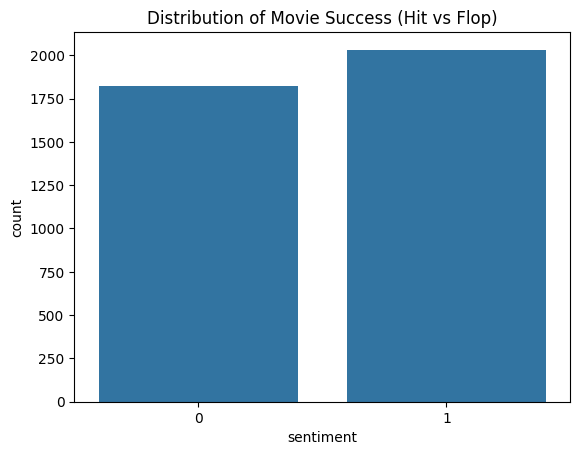

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Movie Success (Hit vs Flop)")
plt.show()

Insight - The dataset is nearly balanced and showing equal distribution of successful and unsuccessful movies.

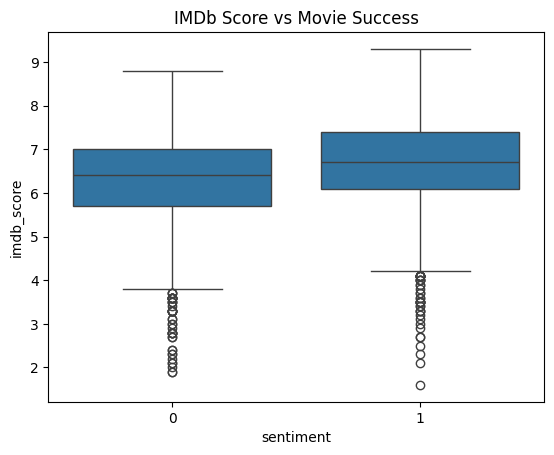

In [16]:
# imdb score vs sentiment
sns.boxplot(x='sentiment', y='imdb_score', data=df)
plt.title("IMDb Score vs Movie Success")
plt.show()

Insight - successful movies tend to  have imdb_score ,indicating that audience ratings are a strong indicator of performance

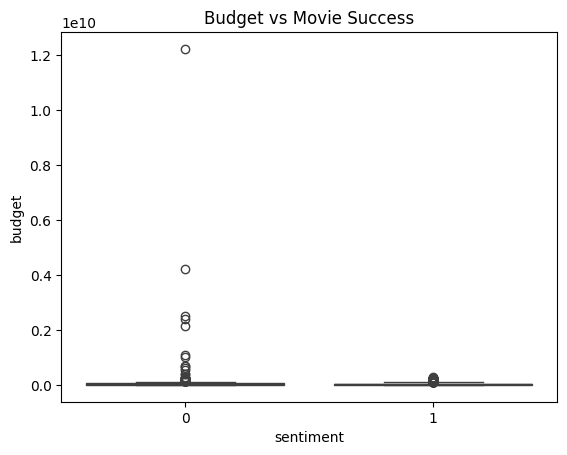

In [17]:
# budget vs sentiment
sns.boxplot(x='sentiment', y='budget', data=df)
plt.title("Budget vs Movie Success")
plt.show()

Insight -There is a significant overlap, suggesting budget alone determine does not determine success.

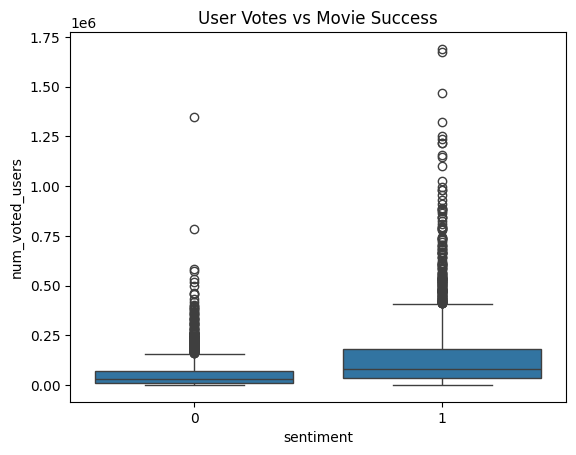

In [18]:
# sentiment vs num_voted_users
sns.boxplot(x='sentiment', y='num_voted_users', data=df)
plt.title("User Votes vs Movie Success")
plt.show()

Insight - movies with higher audience engagement(votes) are more likely to be successful

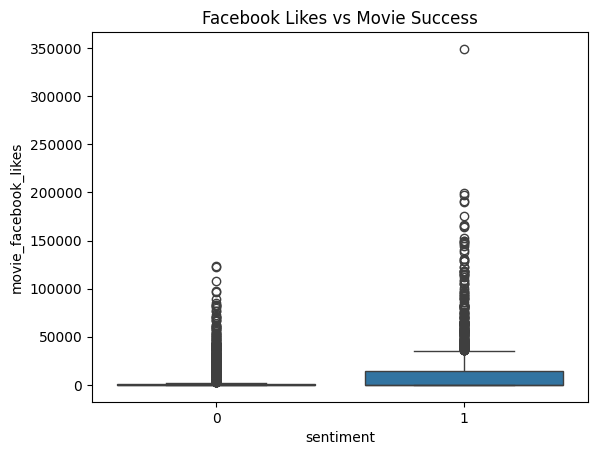

In [19]:
sns.boxplot(x='sentiment', y='movie_facebook_likes', data=df)
plt.title("Facebook Likes vs Movie Success")
plt.show()

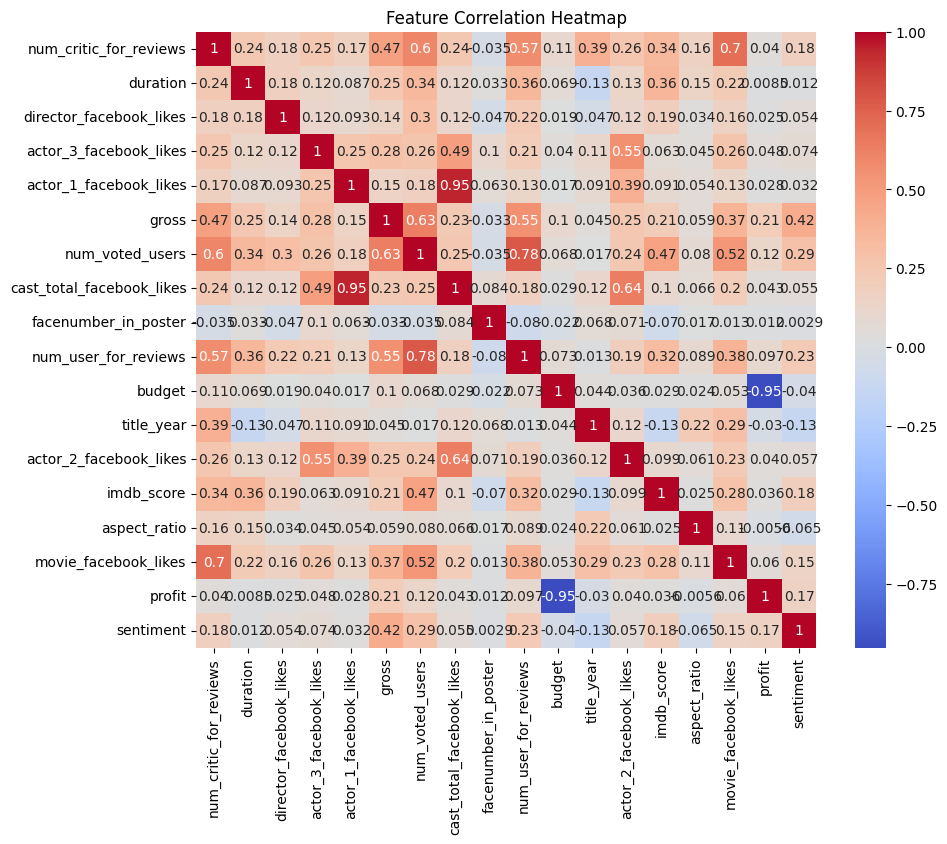

In [21]:
# correlation heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])

# Plot raw numeric values
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Insight - features like gross, num_voted_users, movie_facebook_likes etc shows strong correlation with movie success

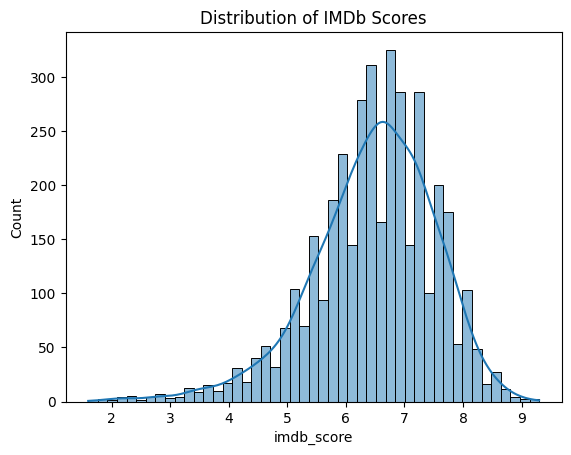

In [22]:
# distribution of imdb score
sns.histplot(df['imdb_score'], kde=True)
plt.title("Distribution of IMDb Scores")
plt.show()

I performed exploratory data analysis using visualizations like box plots and heatmaps to understand feature relationships and identify key drivers of movie success.

New features

In [23]:
df['budget_per_vote'] = df['budget'] / (df['num_voted_users'] + 1)

In [24]:
df['likes_ratio'] = df['movie_facebook_likes'] / (df['num_voted_users'] + 1)

In [25]:
df['engagement_score'] = df['num_voted_users'] * df['imdb_score']

In [26]:
import numpy as np

df['log_budget'] = np.log1p(df['budget'])
df['log_votes'] = np.log1p(df['num_voted_users'])

I created interaction-based and normalized features to better capture relationships between audience engagement, budget, and movie success.

In [27]:
df['sentiment'].value_counts()

,count
sentiment,
1,2032
0,1825


In [28]:
df[cat_cols].head()

,color,director_name,actor_2_name,genres,actor_1_name,movie_title,actor_3_name,plot_keywords,movie_imdb_link,language,country,content_rating
0,Color,James Cameron,Joel David Moore,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,Wes Studi,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,English,USA,PG-13
1,Color,Gore Verbinski,Orlando Bloom,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,Jack Davenport,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,English,USA,PG-13
2,Color,Sam Mendes,Rory Kinnear,Action|Adventure|Thriller,Christoph Waltz,Spectre,Stephanie Sigman,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,English,UK,PG-13
3,Color,Christopher Nolan,Christian Bale,Action|Thriller,Tom Hardy,The Dark Knight Rises,Joseph Gordon-Levitt,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,English,USA,PG-13
5,Color,Andrew Stanton,Samantha Morton,Action|Adventure|Sci-Fi,Daryl Sabara,John Carter,Polly Walker,alien|american civil war|male nipple|mars|prin...,http://www.imdb.com/title/tt0401729/?ref_=fn_t...,English,USA,PG-13


 -> .Well there are high cardinality features instead of encoding dropping them to reduce noise,

In [29]:
cols_to_drop =['movie_title', 'director_name',
    'actor_1_name', 'actor_2_name', 'actor_3_name',
    'plot_keywords', 'movie_imdb_link'
]
df.drop(columns =cols_to_drop, inplace =True ,errors ='ignore')

In [30]:
df['genres'].isnull().sum()

np.int64(0)

In [31]:
df['genres'] = df['genres'].astype(str)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3857 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      3857 non-null   object 
 1   num_critic_for_reviews     3857 non-null   float64
 2   duration                   3857 non-null   float64
 3   director_facebook_likes    3857 non-null   float64
 4   actor_3_facebook_likes     3857 non-null   float64
 5   actor_1_facebook_likes     3857 non-null   float64
 6   gross                      3857 non-null   float64
 7   genres                     3857 non-null   object 
 8   num_voted_users            3857 non-null   float64
 9   cast_total_facebook_likes  3857 non-null   float64
 10  facenumber_in_poster       3857 non-null   float64
 11  num_user_for_reviews       3857 non-null   float64
 12  language                   3857 non-null   object 
 13  country                    3857 non-null   object 
 1

In [33]:
df['genres'] = df['genres'].str.split('|')

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df['genres']),
    columns=mlb.classes_,
    index=df.index
)

df = pd.concat([df.drop('genres', axis=1), genre_encoded], axis=1)

In [34]:
df =pd.get_dummies(df, columns =['color','country','language', 'content_rating'], drop_first =True)

In [35]:
df.shape

(3857, 140)

In [ ]:
df.columns

Index(['num_critic_for_reviews', 'duration', 'director_facebook_likes',
       'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross',
       'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster',
       'num_user_for_reviews',
       ...
       'content_rating_GP', 'content_rating_M', 'content_rating_NC-17',
       'content_rating_Not Rated', 'content_rating_PG', 'content_rating_PG-13',
       'content_rating_Passed', 'content_rating_R', 'content_rating_Unrated',
       'content_rating_X'],
      dtype='object', length=140)

In [36]:
df.isnull().sum()

,0
num_critic_for_reviews,0
duration,0
director_facebook_likes,0
actor_3_facebook_likes,0
actor_1_facebook_likes,0
...,...
content_rating_PG-13,0
content_rating_Passed,0
content_rating_R,0
content_rating_Unrated,0


In [37]:
X =df.drop(['sentiment','profit', 'gross'], axis =1)
y =df['sentiment']

In [38]:
X_train,X_test, y_train, y_test =train_test_split(X,y, test_size =0.2, random_state =42)

In [39]:
scaler =StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

In [40]:
print(X.shape)
print(y.shape)

(3857, 137)
(3857,)


 ->...Building Neural Network

In [41]:
model =Sequential()
# input layer + hidden layer
model.add(Dense(128, activation ='relu',input_dim =X_train_scaled.shape[1]))
model.add(Dropout(0.3))

# hidden layer
model.add(Dense(64, activation ='relu'))
model.add(Dropout(0.3))

# hidden layer
model.add(Dense(32, activation ='relu'))

# output layer
model.add(Dense(1, activation ='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


->... Compile the model


In [42]:
model.compile(optimizer ='adam',loss ='binary_crossentropy', metrics =['accuracy'])

--ADD early stopping

In [44]:
from tensorflow.keras.callbacks import EarlyStopping
early_stops =EarlyStopping(monitor ='val_loss',patience =5,
                        restore_best_weights =True
                           )

---> Train the model

In [45]:
history =model.fit(X_train_scaled, y_train,validation_split =0.2, epochs =50,
                   batch_size =32, callbacks =[early_stops])

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6106 - loss: 0.6740 - val_accuracy: 0.7034 - val_loss: 0.5983
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6921 - loss: 0.6010 - val_accuracy: 0.7293 - val_loss: 0.5605
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7196 - loss: 0.5663 - val_accuracy: 0.7358 - val_loss: 0.5419
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7435 - loss: 0.5324 - val_accuracy: 0.7229 - val_loss: 0.5364
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7686 - loss: 0.5013 - val_accuracy: 0.7342 - val_loss: 0.5353
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7674 - loss: 0.4853 - val_accuracy: 0.7342 - val_loss: 0.5256
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7650 - loss: 0.4771 - val_accuracy: 0.7310 - val_loss: 0.5286
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7751 - loss: 0.4691 - val_accuracy: 0.7423 - val_loss:

In [46]:
from sklearn.metrics import accuracy_score
loss, accuracy = model.evaluate(X_test_scaled, y_test)

print("Test Accuracy:", accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7526 - loss: 0.5459 
Test Accuracy: 0.7525906562805176


In [47]:
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [48]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("accuracy_score:",accuracy_score(y_test, y_pred))

[[259  95]
 [ 96 322]]
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       354
           1       0.77      0.77      0.77       418

    accuracy                           0.75       772
   macro avg       0.75      0.75      0.75       772
weighted avg       0.75      0.75      0.75       772

accuracy_score: 0.7525906735751295


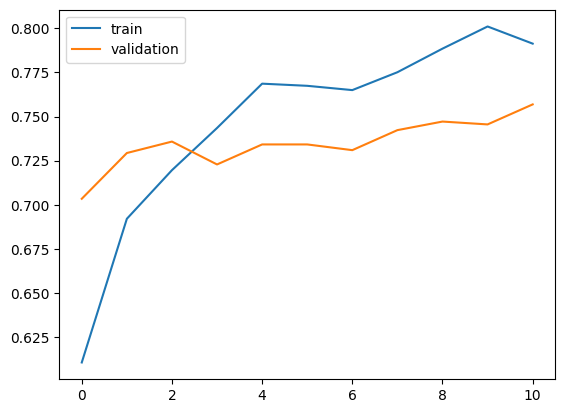

In [49]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()

In [50]:
history.history['accuracy']

[0.6106159090995789,
 0.6920583248138428,
 0.7196110486984253,
 0.7435170412063599,
 0.768638551235199,
 0.7674230337142944,
 0.7649918794631958,
 0.7751215696334839,
 0.7884926795959473,
 0.8010534644126892,
 0.791329026222229]

In [51]:

history.history['val_accuracy']

[0.7034035921096802,
 0.7293354868888855,
 0.7358185052871704,
 0.7228525280952454,
 0.734197735786438,
 0.734197735786438,
 0.7309562563896179,
 0.7423014640808105,
 0.747163712978363,
 0.7455429434776306,
 0.7568881511688232]

In [ ]:
print(len(X_test_scaled))

772


In [52]:
print(len(y_test))

772


Random Forest model

In [53]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=params,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   verbose=1)

In [54]:
rf_model =random_search.best_estimator_
rf_model

RandomForestClassifier(min_samples_leaf=2, min_samples_split=10,
                       n_estimators=200)

In [55]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=10,
                       n_estimators=200)

In [56]:
rf_pred = rf_model.predict(X_test)

In [57]:
from sklearn.metrics import recall_score
print("accuracy:", accuracy_score(y_test, rf_pred))
print("recall:", recall_score(y_test, rf_pred))
print("confusion matrix:",confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

accuracy: 0.7655440414507773
recall: 0.7679425837320574
confusion matrix: [[270  84]
 [ 97 321]]
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       354
           1       0.79      0.77      0.78       418

    accuracy                           0.77       772
   macro avg       0.76      0.77      0.76       772
weighted avg       0.77      0.77      0.77       772



--->I performed hyperparameter tuning using RandomizedSearchCV to optimize the Random Forest model, improving performance while avoiding excessive computation.

--> Business Insight -
 .   

* High budget movies tend to perform better
* Movies with high social media engagement (likes) show higher success
* IMDb score strongly influences success










# **XGBoost Model**

In [58]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier()

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

xgb_model = RandomizedSearchCV(
    xgb,
    param_distributions=params,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1.0]},
                   verbose=1)

In [59]:
best_xgb = random_search.best_estimator_
xgb_pred = best_xgb.predict(X_test)

In [60]:
# Evaluation
print("accuracy:", accuracy_score(y_test, xgb_pred))
print("recall:", recall_score(y_test, xgb_pred))
print("confusion matrix:",confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

accuracy: 0.7655440414507773
recall: 0.7679425837320574
confusion matrix: [[270  84]
 [ 97 321]]
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       354
           1       0.79      0.77      0.78       418

    accuracy                           0.77       772
   macro avg       0.76      0.77      0.76       772
weighted avg       0.77      0.77      0.77       772



In [61]:
df.corr()['sentiment'].sort_values(ascending=False)

,sentiment
sentiment,1.000000
gross,0.418314
log_votes,0.346735
num_voted_users,0.289921
engagement_score,0.272903
...,...
language_French,-0.077211
Drama,-0.085338
country_France,-0.101149
budget_per_vote,-0.103265


In [62]:
importance = best_xgb.feature_importances_
importance

array([3.88045300e-02, 3.11820194e-02, 2.76182628e-02, 3.00560487e-02,
       2.91529559e-02, 7.80337794e-02, 3.06330430e-02, 1.45765863e-02,
       5.27616185e-02, 4.40451473e-02, 5.16174490e-02, 2.93102067e-02,
       3.39743138e-02, 1.32851265e-02, 2.36592835e-02, 1.26957854e-01,
       2.35871823e-02, 6.52293874e-02, 4.14712158e-02, 6.91440593e-02,
       8.82283240e-03, 3.82533425e-03, 1.93124523e-03, 1.91151373e-03,
       8.13082714e-03, 4.99249704e-03, 7.77858831e-04, 8.24309694e-03,
       6.58579992e-03, 3.12143490e-03, 0.00000000e+00, 1.13241828e-03,
       4.05624909e-03, 2.54674399e-03, 8.92307951e-04, 2.72427538e-03,
       5.05204807e-03, 5.06580570e-03, 1.45080376e-05, 1.16910814e-03,
       5.72672981e-03, 1.87542442e-03, 3.13274553e-04, 1.29017659e-03,
       4.17196856e-05, 0.00000000e+00, 2.72196176e-04, 0.00000000e+00,
       1.96999296e-05, 7.51143252e-04, 0.00000000e+00, 3.32787212e-05,
       0.00000000e+00, 0.00000000e+00, 3.64925063e-04, 0.00000000e+00,
      

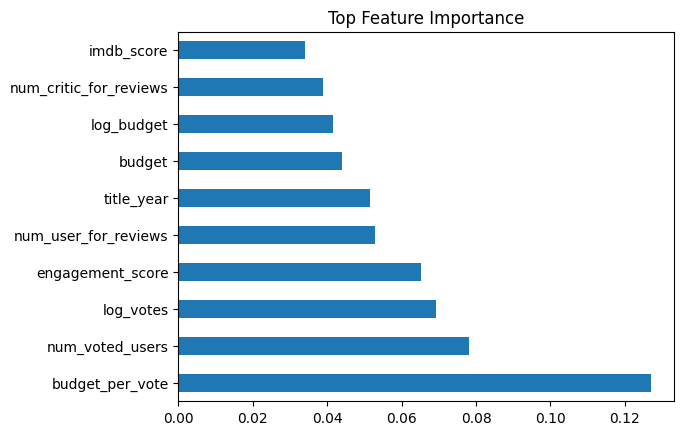

In [63]:
import pandas as pd

importance = best_xgb.feature_importances_

feat_importance = pd.Series(importance, index=X.columns)
feat_importance.nlargest(10).plot(kind='barh')

plt.title("Top Feature Importance")
plt.show()

--> Engineered features significantly influenced predictions

**Conlusion** - Multiple models were evaluated including ANN, Random Forest, and XGBoost. Tree-based models outperformed deep learning due to the structured nature of the dataset. Random Forest and XGBoost achieved similar performance (~77%), indicating stable and reliable predictions.

Model comparison-


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ANN
ann_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")

ann_acc = accuracy_score(y_test, ann_pred)
ann_prec = precision_score(y_test, ann_pred)
ann_rec = recall_score(y_test, ann_pred)
ann_f1 = f1_score(y_test, ann_pred)

# Random Forest
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

# XGBoost
xgb_pred = best_xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
# ANN
print(ann_acc)
print(ann_rec)
# Random Forest
print(rf_acc)
print(rf_rec)
#XGBoost
print(xgb_acc)
print(xgb_rec)

0.6968911917098446
0.777511961722488
0.7616580310880829
0.7799043062200957
0.7616580310880829
0.7799043062200957


Business Insight -The analysis shows that audience engagement, IMDb ratings, and social media presence are strong indicators of movie success. Budget alone is not a reliable predictor, as efficiency and audience reception play a more critical role. Feature engineering revealed that combining variables provides better predictive insights than using individual features.

In [67]:
from joblib import dump, load

# save
dump(model, "model.pkl")
# load
model =load('model.pkl')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
from joblib import dump

dump(model, "/content/drive/MyDrive/model.pkl")

['/content/drive/MyDrive/model.pkl']

In [ ]:
import os
print(os.listdir())

['.config', 'movie_metadata.csv', 'model.pkl', 'models', 'drive', 'sample_data']
